# ConverterIQ — Exploratory Data Analysis of `id_mea_2`

This notebook documents the initial EDA for the instantaneous three-phase current dataset used by ConverterIQ.

**Primary goals**

1. Validate dataset integrity and label distribution.
2. Understand the temporal acquisition structure.
3. Reconstruct label runs and candidate fault-injection episodes.
4. Verify the waveform layout and physical plausibility.
5. Quantify within-episode redundancy and cross-episode variation.
6. Produce modeling decisions, especially an episode-aware train/validation/test split.

> **EDA scope:** Detailed signal analysis is not repeated for all 47 fault classes at this stage. `id_error=12` is used as a representative case study to test redundancy and cross-episode variation. After a baseline model is trained, confusion matrices and per-class metrics should drive any deeper class-specific EDA.

## 0. Setup

In [2]:
from pathlib import Path
from collections import Counter

import ijson
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/id_mea_2.json")

## 1. Dataset audit

The first pass streams through the JSON file instead of loading the full waveform dataset into memory.  
We verify record count, label counts, waveform length, experiment ID, and device ID.

In [3]:
n_records = 0
label_counts = Counter()
mea_lengths = Counter()
experiment_counts = Counter()
device_counts = Counter()

first_record = None

with DATA_PATH.open("rb") as f:
    for record in ijson.items(f, "item"):
        if first_record is None:
            first_record = record

        n_records += 1
        label_counts[record["id_error"]] += 1
        mea_lengths[len(record["mea_value"])] += 1
        experiment_counts[record.get("experiment_id")] += 1
        device_counts[record.get("device")] += 1

print("Number of records:", n_records)
print("Record keys:", first_record.keys())
print("First id_error:", first_record["id_error"])
print("First id_mea:", first_record["id_mea"])
print("mea_value length distribution:", mea_lengths)

print("\nLabels:")
for label, count in sorted(label_counts.items()):
    print(label, count)

print("\nExperiments:")
print(experiment_counts)

print("\nDevices:")
print(device_counts)

Number of records: 386705
Record keys: dict_keys(['_id', 'timestamp', 'device', 'id_mea', 'id_error', 'mea_value', 'experiment_id', 'store_timestamp'])
First id_error: 0
First id_mea: 2
mea_value length distribution: Counter({60: 386705})

Labels:
0 277041
1 2388
2 2265
3 2306
4 2333
5 2424
6 2375
7 2272
8 2300
9 2202
10 2294
11 2218
12 2445
13 2666
14 2512
15 2578
16 2552
17 2571
18 2631
19 2541
20 2702
21 2654
22 2661
23 2499
24 2494
25 2698
26 2566
27 2588
28 2546
29 2397
30 2277
31 2238
32 2216
33 2312
34 2281
35 2223
36 2326
37 2300
38 2104
39 1989
40 2007
41 1936
42 1959
43 1868
44 2022
45 1967
46 1948
47 2013

Experiments:
Counter({'experiment_3': 386705})

Devices:
Counter({'test1': 386705})


### Dataset audit findings

- **386,705 records** are present.
- Every record contains exactly **60 waveform values**.
- All **48 labels** (`id_error = 0–47`) are present.
- Healthy (`id_error=0`) contains **277,041 records (~71.6%)**; all faults together contain **109,664 records (~28.4%)**.
- Individual fault classes are relatively balanced compared with one another (roughly 1.9k–2.7k records per class).
- All records come from `experiment_3` and device `test1`, so these fields cannot be used as natural grouping variables for train/test splitting.

**Modeling implication:** the primary class imbalance is healthy versus each individual fault class. Overall accuracy alone will therefore be insufficient; macro-F1 and per-class recall should be emphasized later.

## 2. Temporal acquisition structure

Only metadata are loaded into a pandas DataFrame. This keeps waveform data on disk while allowing timestamp, label-transition, and episode analysis.

In [ ]:
rows = []

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):
        rows.append({
            "row_id": i,
            "timestamp": record["timestamp"],
            "store_timestamp": record["store_timestamp"],
            "id_error": record["id_error"],
        })

meta = pd.DataFrame(rows)
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 386705 entries, 0 to 386704
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   row_id           386705 non-null  int64 
 1   timestamp        386705 non-null  object
 2   store_timestamp  386705 non-null  object
 3   id_error         386705 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 11.8+ MB
0    1778621652.8690739
1    1778621655.1941433
2     1778621655.273921
3    1778621655.8842247
4    1778621659.9087675
5    1778621659.9924388
6    1778621660.0760171
7    1778621660.1583745
8    1778621660.8651075
9    1778621661.8660812
Name: timestamp, dtype: object
386695     1779019531.016028
386696    1779019532.0175765
386697     1779019533.017365
386698     1779019534.018869
386699    1779019535.0206363
386700    1779019536.0206144
386701    1779019537.0205538
386702     1779019538.017531
386703    1779019539.0201006
386704    1779019540.0190635
Name: timesta

`ijson` parses JSON numbers as `Decimal`, so timestamps are first converted to floating-point Unix seconds and then to UTC datetimes.  
The original timestamp columns are preserved.

In [11]:
meta["timestamp_num"] = meta["timestamp"].astype(float)
meta["store_timestamp_num"] = meta["store_timestamp"].astype(float)

meta["timestamp_dt"] = pd.to_datetime(
    meta["timestamp_num"],
    unit="s",
    utc=True
)

meta["store_timestamp_dt"] = pd.to_datetime(
    meta["store_timestamp_num"],
    unit="s",
    utc=True
)

### 2.1 Normal inter-record cadence

In [12]:
meta["dt_seconds"] = meta["timestamp_num"].diff()

print("Timestamp monotonic:")
print(meta["timestamp_num"].is_monotonic_increasing)

print("\nDuplicate timestamps:")
print(meta["timestamp_num"].duplicated().sum())

print("\nTime-gap summary:")
print(meta["dt_seconds"].describe())

print("\nMost common time gaps:")
print(meta["dt_seconds"].round(3).value_counts().head(20))

Timestamp monotonic:
True

Duplicate timestamps:
0

Time-gap summary:
count    386704.000000
mean          1.028919
std          17.923744
min           0.071163
25%           0.998573
50%           0.999992
75%           1.001433
max       11146.931422
Name: dt_seconds, dtype: float64

Most common time gaps:
dt_seconds
1.000    75217
0.999    63318
1.001    62155
0.998    41927
1.002    41507
1.003    25192
0.997    24722
1.004    13817
0.996    13625
0.995     6562
1.005     6545
1.006     3028
0.994     2957
0.993     1458
1.007     1423
0.992      700
1.008      698
1.009      388
0.991      367
1.010      220
Name: count, dtype: int64


In [18]:
meta["dt_seconds"].quantile([
    0.99,
    0.995,
    0.999,
    0.9995,
    0.9999
])

0.9900    1.006140
0.9950    1.007232
0.9990    1.010139
0.9995    1.011779
0.9999    1.019106
Name: dt_seconds, dtype: float64

The median timestamp gap is essentially **1 second**, and even the 99.99th percentile is only about **1.019 s**.  
Thus, the normal logging cadence is approximately **1 Hz**.

### 2.2 Measurement timestamp vs. storage timestamp

In [14]:
meta["store_delay"] = (
    meta["store_timestamp_num"]
    - meta["timestamp_num"]
)

print(meta["store_delay"].describe())

count    386705.000000
mean          0.004899
std           0.222752
min           0.002457
25%           0.002784
50%           0.002855
75%           0.002953
max          37.556698
Name: store_delay, dtype: float64


The median storage delay is only a few milliseconds, but rare storage-delay outliers exist.  
For sequence analysis, the measurement `timestamp` is therefore used rather than `store_timestamp`.

### 2.3 Rare acquisition gaps

In [16]:
meta["prev_id_error"] = meta["id_error"].shift()

thresholds = [1.05, 1.1, 1.2, 1.5, 2, 5, 10, 60]

for t in thresholds:
    mask = meta["dt_seconds"] > t

    total = mask.sum()
    same_label = (
        mask &
        (meta["id_error"] == meta["prev_id_error"])
    ).sum()

    changed_label = (
        mask &
        (meta["id_error"] != meta["prev_id_error"])
    ).sum()

    print(
        f"> {t:>5} sec: "
        f"{total:>6} gaps | "
        f"same label: {same_label:>6} | "
        f"label changed: {changed_label:>6}"
    )

>  1.05 sec:     21 gaps | same label:     20 | label changed:      1
>   1.1 sec:     17 gaps | same label:     17 | label changed:      0
>   1.2 sec:     15 gaps | same label:     15 | label changed:      0
>   1.5 sec:     15 gaps | same label:     15 | label changed:      0
>     2 sec:     12 gaps | same label:     12 | label changed:      0
>     5 sec:      2 gaps | same label:      2 | label changed:      0
>    10 sec:      2 gaps | same label:      2 | label changed:      0
>    60 sec:      1 gaps | same label:      1 | label changed:      0


In [19]:
for center in [137990, 214427]:
    display(
        meta.loc[
            center-5:center+5,
            [
                "row_id",
                "timestamp_dt",
                "id_error",
                "dt_seconds"
            ]
        ]
    )

,row_id,timestamp_dt,id_error,dt_seconds
137985,137985,2026-05-14 11:54:04.947927475+00:00,0,1.001076
137986,137986,2026-05-14 11:54:05.945552826+00:00,0,0.997625
137987,137987,2026-05-14 11:54:06.948991299+00:00,0,1.003438
137988,137988,2026-05-14 11:54:07.943994999+00:00,0,0.995004
137989,137989,2026-05-14 11:54:08.945451260+00:00,0,1.001456
137990,137990,2026-05-14 14:59:55.876873016+00:00,0,11146.931422
137991,137991,2026-05-14 14:59:56.875179291+00:00,0,0.998306
137992,137992,2026-05-14 14:59:57.878807783+00:00,0,1.003628
137993,137993,2026-05-14 14:59:58.876052380+00:00,0,0.997245
137994,137994,2026-05-14 14:59:59.874919653+00:00,0,0.998867


,row_id,timestamp_dt,id_error,dt_seconds
214422,214422,2026-05-15 12:13:47.915809393+00:00,0,1.000772
214423,214423,2026-05-15 12:13:48.917181969+00:00,0,1.001373
214424,214424,2026-05-15 12:13:49.913019657+00:00,0,0.995838
214425,214425,2026-05-15 12:13:50.916508198+00:00,0,1.003489
214426,214426,2026-05-15 12:13:51.913485289+00:00,0,0.996977
214427,214427,2026-05-15 12:14:22.917989016+00:00,0,31.004504
214428,214428,2026-05-15 12:14:23.912441492+00:00,0,0.994452
214429,214429,2026-05-15 12:14:24.914433479+00:00,0,1.001992
214430,214430,2026-05-15 12:14:25.915557623+00:00,0,1.001124
214431,214431,2026-05-15 12:14:26.914866447+00:00,0,0.999309


### Temporal sampling conclusion

Records are chronologically ordered with no duplicate timestamps. Under normal acquisition, records are logged at approximately **1 Hz**; 99.99% of consecutive gaps are below approximately **1.019 s**.

A small number of acquisition interruptions exist, including pauses of roughly **31 s** and **3.1 h**. Inspection around the two largest gaps shows that the label remains healthy before and after the interruption and that the normal ~1 s cadence immediately resumes. These gaps are therefore more consistent with logging/acquisition pauses than fault transitions.

Each row should be interpreted as a **one-cycle waveform snapshot sampled approximately once per second**, rather than as part of one continuous 1 kHz waveform stream.

## 3. Label runs and candidate fault episodes

Three levels are distinguished:

- **Raw record:** one row in the JSON file.
- **Label run:** a contiguous block of rows with the same `id_error`.
- **Fault episode:** a non-zero label run, interpreted as one candidate fault injection.

For example, a raw sequence such as `0,0,0,12,12,12,0,0` becomes the label-run sequence `0 → 12 → 0`.

In [15]:
meta["label_changed"] = (
    meta["id_error"] != meta["id_error"].shift()
)

transitions = meta.loc[
    meta["label_changed"],
    ["row_id", "timestamp_dt", "id_error", "dt_seconds"]
]

print("Number of label runs:", len(transitions))
print(transitions.head(30))

Number of label runs: 33627
     row_id                        timestamp_dt  id_error  dt_seconds
0         0 2026-05-12 21:34:12.869073868+00:00         0         NaN
7         7 2026-05-12 21:34:20.158374548+00:00        12    0.082357
14       14 2026-05-12 21:34:26.901550770+00:00         0    0.075551
33       33 2026-05-12 21:34:45.869945765+00:00        12    0.151494
41       41 2026-05-12 21:34:53.870015860+00:00         0    0.876565
57       57 2026-05-12 21:35:09.867588758+00:00        12    0.992906
62       62 2026-05-12 21:35:14.870400190+00:00         0    0.997851
76       76 2026-05-12 21:35:28.866329908+00:00        12    0.997608
81       81 2026-05-12 21:35:33.867072344+00:00         0    0.996821
97       97 2026-05-12 21:35:49.870922804+00:00        12    1.002487
100     100 2026-05-12 21:35:52.869074345+00:00         0    0.998506
121     121 2026-05-12 21:36:13.866118431+00:00        12    0.997285
127     127 2026-05-12 21:36:19.870252848+00:00         0    1

In [20]:
meta["new_label_run"] = (
    meta["id_error"] != meta["id_error"].shift()
)

meta["label_run_id"] = meta["new_label_run"].cumsum()

In [21]:
run_summary = (
    meta.groupby("label_run_id")
    .agg(
        id_error=("id_error", "first"),
        n_records=("id_error", "size"),
        start_row=("row_id", "first"),
        end_row=("row_id", "last"),
        start_time=("timestamp_dt", "first"),
        end_time=("timestamp_dt", "last"),
    )
    .reset_index()
)

run_summary["duration_seconds"] = (
    run_summary["end_time"]
    - run_summary["start_time"]
).dt.total_seconds()

In [22]:
print("Number of label runs:", len(run_summary))

print("\nRun summary:")
print(run_summary["n_records"].describe())

Number of label runs: 33627

Run summary:
count    33627.000000
mean        11.499836
std          5.751751
min          2.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         64.000000
Name: n_records, dtype: float64


### 3.1 Healthy versus fault run lengths

In [23]:
healthy_runs = run_summary[
    run_summary["id_error"] == 0
]

fault_runs = run_summary[
    run_summary["id_error"] != 0
]

print("Healthy runs:", len(healthy_runs))
print("Fault runs:", len(fault_runs))

print("\nHealthy run lengths:")
print(healthy_runs["n_records"].describe())

print("\nFault run lengths:")
print(fault_runs["n_records"].describe())

Healthy runs: 16814
Fault runs: 16813

Healthy run lengths:
count    16814.000000
mean        16.476805
std          2.907590
min          7.000000
25%         14.000000
50%         16.000000
75%         19.000000
max         64.000000
Name: n_records, dtype: float64

Fault run lengths:
count    16813.000000
mean         6.522572
std          2.857766
min          2.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         11.000000
Name: n_records, dtype: float64


### 3.2 Episode counts by label

In [24]:
per_class_runs = (
    run_summary
    .groupby("id_error")
    .agg(
        n_runs=("label_run_id", "count"),
        total_records=("n_records", "sum"),
        mean_records_per_run=("n_records", "mean"),
        median_records_per_run=("n_records", "median"),
        min_records_per_run=("n_records", "min"),
        max_records_per_run=("n_records", "max"),
    )
)

per_class_runs

,n_runs,total_records,mean_records_per_run,median_records_per_run,min_records_per_run,max_records_per_run
id_error,,,,,,
0,16814,277041,16.476805,16.0,7,64
1,350,2388,6.822857,7.0,2,11
2,350,2265,6.471429,7.0,2,11
3,350,2306,6.588571,7.0,2,11
4,350,2333,6.665714,7.0,2,11
5,350,2424,6.925714,7.0,2,11
6,350,2375,6.785714,7.0,2,11
7,350,2272,6.491429,7.0,2,11
8,350,2300,6.571429,7.0,2,11


### 3.3 Transition structure

In [25]:
run_summary["prev_label"] = run_summary["id_error"].shift()
run_summary["next_label"] = run_summary["id_error"].shift(-1)

In [26]:
healthy_to_fault = (
    (run_summary["prev_label"] == 0)
    & (run_summary["id_error"] != 0)
).sum()

fault_to_healthy = (
    (run_summary["prev_label"] != 0)
    & (run_summary["id_error"] == 0)
).sum()

fault_to_fault = (
    (run_summary["prev_label"] != 0)
    & (run_summary["id_error"] != 0)
).sum()

print("Healthy -> Fault:", healthy_to_fault)
print("Fault -> Healthy:", fault_to_healthy)
print("Fault -> Fault:", fault_to_fault)

Healthy -> Fault: 16813
Fault -> Healthy: 16814
Fault -> Fault: 0


In [27]:
fault_run_context = run_summary[
    run_summary["id_error"] != 0
].copy()

fault_run_context["healthy_before"] = (
    fault_run_context["prev_label"] == 0
)

fault_run_context["healthy_after"] = (
    fault_run_context["next_label"] == 0
)

print(
    fault_run_context[
        ["healthy_before", "healthy_after"]
    ].value_counts()
)

healthy_before  healthy_after
True            True             16813
Name: count, dtype: int64


The run sequence alternates cleanly between healthy and fault states:

- **Healthy → Fault:** 16,813
- **Fault → Healthy:** 16,814
- **Fault → Fault:** 0

Every fault run is preceded and followed by a healthy run. This strongly supports treating each contiguous non-zero run as one **candidate fault-injection episode**.

In [30]:
fault_episodes = (
    run_summary[run_summary["id_error"] != 0]
    .copy()
    .reset_index(drop=True)
)

fault_episodes.insert(
    0,
    "fault_episode_id",
    np.arange(1, len(fault_episodes) + 1)
)

print("Fault episode table shape:", fault_episodes.shape)
display(fault_episodes.head())

print("\nFault episodes per class:")
display(fault_episodes["id_error"].value_counts().sort_index())

,fault_episode_id,label_run_id,id_error,n_records,start_row,end_row,start_time,end_time,duration_seconds,prev_label,next_label
0,1,2,12,7,7,13,2026-05-12 21:34:20.158374548+00:00,2026-05-12 21:34:26.825999498+00:00,6.667625,0.0,0.0
1,2,4,12,8,33,40,2026-05-12 21:34:45.869945765+00:00,2026-05-12 21:34:52.993451118+00:00,7.123505,0.0,0.0
2,3,6,12,5,57,61,2026-05-12 21:35:09.867588758+00:00,2026-05-12 21:35:13.872549057+00:00,4.004960,0.0,0.0
3,4,8,12,5,76,80,2026-05-12 21:35:28.866329908+00:00,2026-05-12 21:35:32.870250940+00:00,4.003921,0.0,0.0
4,5,10,12,3,97,99,2026-05-12 21:35:49.870922804+00:00,2026-05-12 21:35:51.870568037+00:00,1.999645,0.0,0.0


id_error
1     350
2     350
3     350
4     350
5     350
6     350
7     350
8     350
9     350
10    350
11    350
12    370
13    400
14    400
15    400
16    400
17    400
18    400
19    400
20    399
21    400
22    400
23    400
24    400
25    400
26    400
27    400
28    400
29    363
30    350
31    350
32    350
33    350
34    350
35    350
36    350
37    350
38    331
39    300
40    300
41    300
42    300
43    300
44    300
45    300
46    300
47    300
Name: count, dtype: int64

### Episode-structure conclusion

The dataset contains **16,813 candidate fault episodes**. Most fault episodes contain approximately **6–7 recorded snapshots** (minimum 2, maximum 11), while healthy runs are longer (median approximately 16 records).

Most fault classes contain roughly **300–400 separate fault episodes**, so their record counts are not produced by only a few long events.

**Critical modeling implication:** train/validation/test splitting must operate at the **episode level**, not the row level.

## 4. Waveform layout validation

Every `mea_value` contains 60 numbers. Two possible layouts were tested:

1. **Block-wise:** 20 Phase-A samples, then 20 Phase-B samples, then 20 Phase-C samples.
2. **Interleaved:** A0, B0, C0, A1, B1, C1, ...

A healthy record is used to visually determine which reconstruction produces a physically plausible balanced three-phase waveform.

In [ ]:
with DATA_PATH.open("rb") as f:
    first_record = next(ijson.items(f, "item"))

values = np.asarray(first_record["mea_value"], dtype=float)

wave_block = values.reshape(3, 20).T
wave_interleaved = values.reshape(20, 3)

print("Label:", first_record["id_error"])
print("Raw shape:", values.shape)
print("Candidate waveform shape:", wave_block.shape)

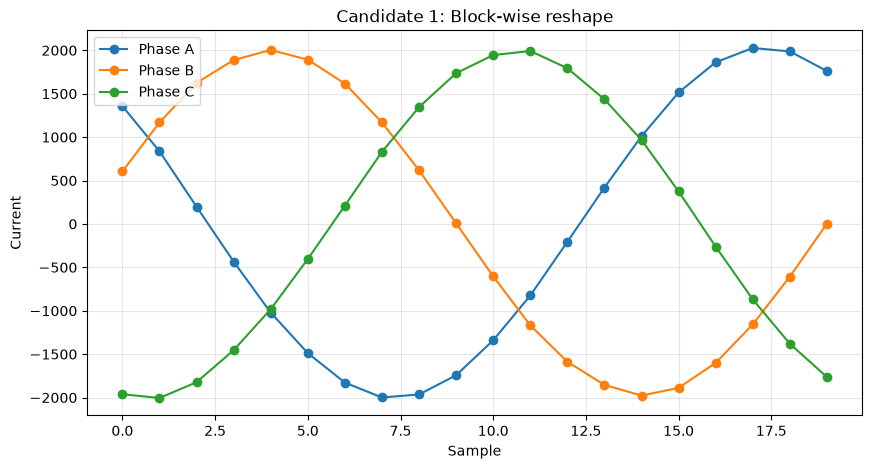

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(wave_block[:, 0], marker="o", label="Phase A")
plt.plot(wave_block[:, 1], marker="o", label="Phase B")
plt.plot(wave_block[:, 2], marker="o", label="Phase C")

plt.xlabel("Sample")
plt.ylabel("Current")
plt.title("Candidate 1: Block-wise reshape")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

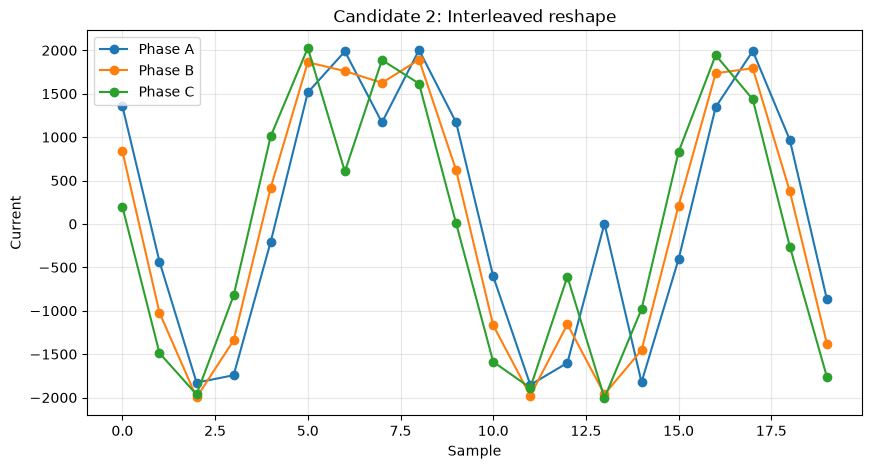

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(wave_interleaved[:, 0], marker="o", label="Phase A")
plt.plot(wave_interleaved[:, 1], marker="o", label="Phase B")
plt.plot(wave_interleaved[:, 2], marker="o", label="Phase C")

plt.xlabel("Sample")
plt.ylabel("Current")
plt.title("Candidate 2: Interleaved reshape")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The **block-wise reconstruction** produces the expected smooth three-phase sinusoidal structure, whereas the interleaved interpretation produces discontinuous traces.  
Therefore, the waveform is stored as:

`A0 ... A19, B0 ... B19, C0 ... C19`.

In [15]:
def reshape_waveform(mea_value):
    values = np.asarray(mea_value, dtype=float)

    if len(values) != 60:
        raise ValueError(
            f"Expected 60 values, got {len(values)}"
        )

    return values.reshape(3, 20).T

## 5. Representative case study: `id_error=12`

A single fault class is examined in detail to answer two modeling questions:

1. Are multiple rows from the **same fault episode** near-duplicates?
2. Do **independent episodes** of the same fault still exhibit variation?

This case study is not intended to characterize all 47 fault classes.

### 5.1 Healthy waveform versus one fault episode

In [37]:
target_rows = set(range(6, 14))

selected_records = {}

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):

        if i in target_rows:
            selected_records[i] = record

        if i > max(target_rows):
            break


for row_id, record in selected_records.items():
    print(
        row_id,
        "label =", record["id_error"]
    )

6 label = 0
7 label = 12
8 label = 12
9 label = 12
10 label = 12
11 label = 12
12 label = 12
13 label = 12


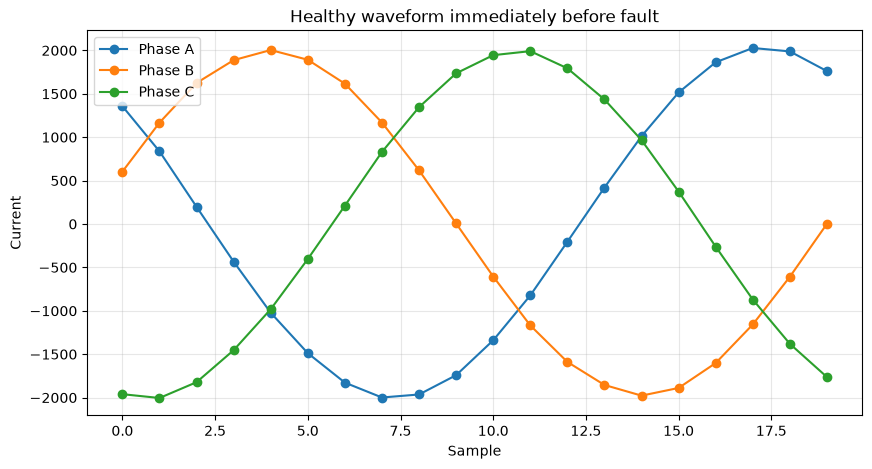

In [38]:
healthy_wave = reshape_waveform(
    selected_records[6]["mea_value"]
)

fault_wave = reshape_waveform(
    selected_records[7]["mea_value"]
)



plt.figure(figsize=(10, 5))

for phase in range(3):
    plt.plot(
        healthy_wave[:, phase],
        marker="o",
        label=f"Phase {chr(65 + phase)}"
    )

plt.title("Healthy waveform immediately before fault")
plt.xlabel("Sample")
plt.ylabel("Current")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

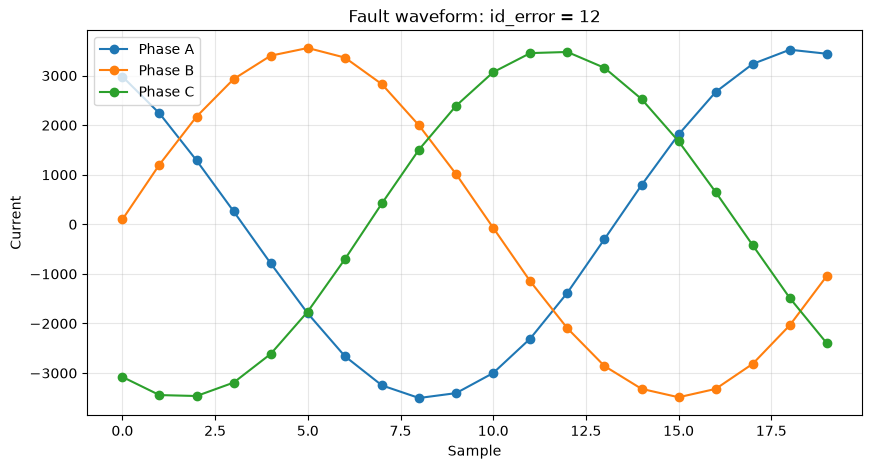

In [39]:
plt.figure(figsize=(10, 5))

for phase in range(3):
    plt.plot(
        fault_wave[:, phase],
        marker="o",
        label=f"Phase {chr(65 + phase)}"
    )

plt.title("Fault waveform: id_error = 12")
plt.xlabel("Sample")
plt.ylabel("Current")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The first examined `id_error=12` episode shows a large change in current magnitude while remaining approximately sinusoidal and zero-centered.  
This is only a case-study observation; it should not be generalized to every `id_error=12` episode without considering operating-condition variation.

In [40]:
def waveform_features(wave):
    return {
        "rms": np.sqrt(np.mean(wave**2, axis=0)),
        "mean": np.mean(wave, axis=0),
        "peak_abs": np.max(np.abs(wave), axis=0),
        "peak_to_peak": np.ptp(wave, axis=0),
    }


healthy_features = waveform_features(healthy_wave)
fault_features = waveform_features(fault_wave)

for name in healthy_features:
    print(f"\n{name}")
    print("Healthy:", healthy_features[name])
    print("Fault 12:", fault_features[name])


rms
Healthy: [1430.05990757 1402.379457   1412.74343215]
Fault 12: [2480.31483157 2495.35718346 2483.17967359]

mean
Healthy: [  6.75657501   6.96879151 -13.72536011]
Fault 12: [ -7.11034088  18.84247894 -11.73218079]

peak_abs
Healthy: [2027.53222656 2003.94299316 2004.50158691]
Fault 12: [3522.51025391 3557.21875    3476.97509766]

peak_to_peak
Healthy: [4026.31872559 3981.21203613 3995.70800781]
Fault 12: [7025.7277832  7045.40649414 6940.0715332 ]


In [41]:
episode_features = []

for row_id in range(7, 14):
    wave = reshape_waveform(
        selected_records[row_id]["mea_value"]
    )

    rms = np.sqrt(np.mean(wave**2, axis=0))

    episode_features.append({
        "row_id": row_id,
        "id_error": selected_records[row_id]["id_error"],
        "rms_A": rms[0],
        "rms_B": rms[1],
        "rms_C": rms[2],
    })

episode_features = pd.DataFrame(episode_features)

episode_features

,row_id,id_error,rms_A,rms_B,rms_C
0,7,12,2480.314832,2495.357183,2483.179674
1,8,12,2476.768620,2494.175790,2490.500735
2,9,12,2472.662792,2491.241756,2476.714339
3,10,12,2475.466047,2487.050052,2481.423154
4,11,12,2477.806821,2497.610896,2482.242670
5,12,12,2468.915949,2495.329390,2472.351345
6,13,12,2453.268023,2500.348445,2466.915453


### 5.2 Within-episode redundancy

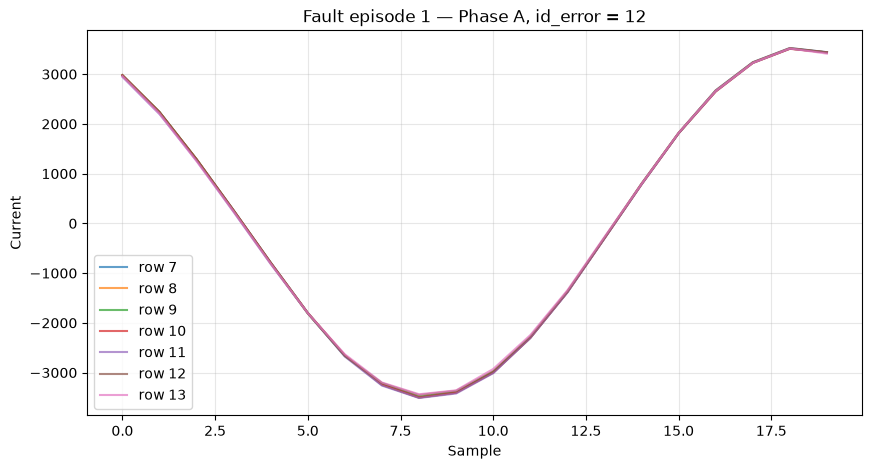

In [43]:
plt.figure(figsize=(10, 5))

for row_id in range(7, 14):
    wave = reshape_waveform(
        selected_records[row_id]["mea_value"]
    )

    plt.plot(
        wave[:, 0],
        alpha=0.7,
        label=f"row {row_id}"
    )

plt.xlabel("Sample")
plt.ylabel("Current")
plt.title("Fault episode 1 — Phase A, id_error = 12")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
episode_phase_a = []

for row_id in range(7, 14):
    wave = reshape_waveform(
        selected_records[row_id]["mea_value"]
    )
    episode_phase_a.append(wave[:, 0])

episode_phase_a = np.array(episode_phase_a)

corr_matrix = np.corrcoef(episode_phase_a)

print(np.round(corr_matrix, 6))

[[1.       0.999998 0.999992 0.999999 0.99999  0.999987 0.999963]
 [0.999998 1.       0.999994 0.999998 0.999989 0.999988 0.999967]
 [0.999992 0.999994 1.       0.999992 0.999986 0.999995 0.999972]
 [0.999999 0.999998 0.999992 1.       0.999986 0.999984 0.999957]
 [0.99999  0.999989 0.999986 0.999986 1.       0.999985 0.999978]
 [0.999987 0.999988 0.999995 0.999984 0.999985 1.       0.999981]
 [0.999963 0.999967 0.999972 0.999957 0.999978 0.999981 1.      ]]


In [45]:
upper_triangle = corr_matrix[
    np.triu_indices_from(corr_matrix, k=1)
]

print("Mean pairwise correlation:",
      upper_triangle.mean())

print("Min pairwise correlation:",
      upper_triangle.min())

print("Max pairwise correlation:",
      upper_triangle.max())

Mean pairwise correlation: 0.999984851205907
Min pairwise correlation: 0.9999569446326718
Max pairwise correlation: 0.9999985340145667


In [47]:
reference = episode_phase_a[0]

reference_rms = np.sqrt(
    np.mean(reference**2)
)

for i, row_id in enumerate(range(7, 14)):
    rmse = np.sqrt(
        np.mean(
            (episode_phase_a[i] - reference) ** 2
        )
    )

    nrmse = rmse / reference_rms

    print(
        f"row {row_id}: "
        f"NRMSE = {nrmse:.6f}"
    )


row 7: NRMSE = 0.000000
row 8: NRMSE = 0.002540
row 9: NRMSE = 0.005017
row 10: NRMSE = 0.002889
row 11: NRMSE = 0.007735
row 12: NRMSE = 0.008260
row 13: NRMSE = 0.014474


### Within-episode finding

For the examined seven-record fault episode:

- Mean pairwise Phase-A correlation is approximately **0.999985**.
- Minimum pairwise correlation remains above **0.99995**.
- NRMSE relative to the first record remains below approximately **1.5%**.

The records are therefore near-duplicates at the waveform level. This provides direct evidence that a random row-level split would leak highly correlated observations across training and evaluation sets.

## 6. Cross-episode variation for the same fault class

To avoid mixing within-episode duplication with genuine repeated experiments, one representative waveform (the first row) is selected from each of the **370 independent `id_error=12` episodes**.

In [53]:
fault12_eps = fault_episodes[
    fault_episodes["id_error"] == 12
].copy()

print(len(fault12_eps))
fault12_eps.head()


370


,fault_episode_id,label_run_id,id_error,n_records,start_row,end_row,start_time,end_time,duration_seconds,prev_label,next_label
0,1,2,12,7,7,13,2026-05-12 21:34:20.158374548+00:00,2026-05-12 21:34:26.825999498+00:00,6.667625,0.0,0.0
1,2,4,12,8,33,40,2026-05-12 21:34:45.869945765+00:00,2026-05-12 21:34:52.993451118+00:00,7.123505,0.0,0.0
2,3,6,12,5,57,61,2026-05-12 21:35:09.867588758+00:00,2026-05-12 21:35:13.872549057+00:00,4.004960,0.0,0.0
3,4,8,12,5,76,80,2026-05-12 21:35:28.866329908+00:00,2026-05-12 21:35:32.870250940+00:00,4.003921,0.0,0.0
4,5,10,12,3,97,99,2026-05-12 21:35:49.870922804+00:00,2026-05-12 21:35:51.870568037+00:00,1.999645,0.0,0.0


In [54]:
fault12_start_rows = set(
    fault12_eps["start_row"].astype(int)
)

fault12_representatives = {}

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):

        if i in fault12_start_rows:
            fault12_representatives[i] = record

        if len(fault12_representatives) == len(fault12_start_rows):
            break

print(len(fault12_representatives))


370


In [55]:
fault12_phase_a = []

for row_id in sorted(fault12_representatives):
    wave = reshape_waveform(
        fault12_representatives[row_id]["mea_value"]
    )

    fault12_phase_a.append(wave[:, 0])

fault12_phase_a = np.array(fault12_phase_a)

print(fault12_phase_a.shape)

(370, 20)


### 6.1 Visual variation across independent episodes

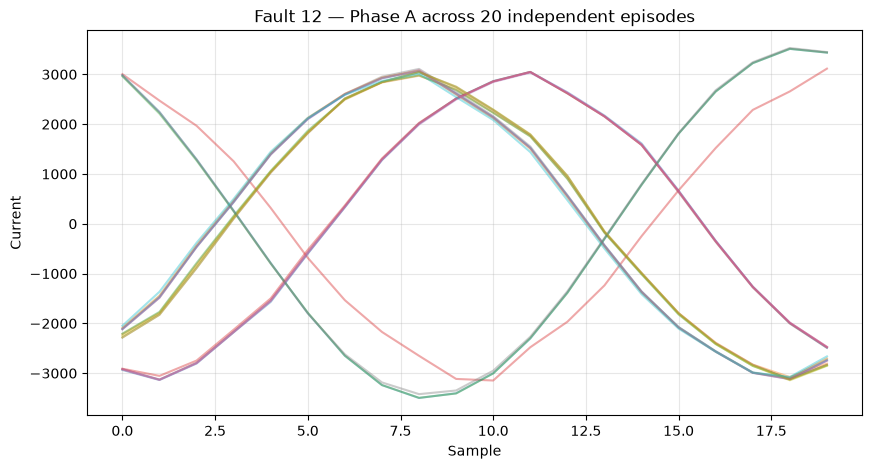

In [57]:
rng = np.random.default_rng(42)

idx = rng.choice(
    len(fault12_phase_a),
    size=20,
    replace=False
)

plt.figure(figsize=(10, 5))

for i in idx:
    plt.plot(
        fault12_phase_a[i],
        alpha=0.4
    )

plt.title(
    "Fault 12 — Phase A across 20 independent episodes"
)
plt.xlabel("Sample")
plt.ylabel("Current")
plt.grid(alpha=0.3)
plt.show()

Independent episodes preserve similar periodic morphology but begin at different electrical phases.  
Raw pointwise correlation is therefore not an appropriate cross-episode similarity measure without phase alignment.

In [58]:
def best_circular_alignment(reference, wave):
    best_corr = -np.inf
    best_shift = None
    best_wave = None

    for shift in range(len(wave)):
        shifted = np.roll(wave, shift)

        corr = np.corrcoef(
            reference,
            shifted
        )[0, 1]

        if corr > best_corr:
            best_corr = corr
            best_shift = shift
            best_wave = shifted

    return best_corr, best_shift, best_wave

In [59]:
reference = fault12_phase_a[0]

aligned_corrs = []
aligned_nrmses = []
best_shifts = []

reference_rms = np.sqrt(
    np.mean(reference**2)
)

for wave in fault12_phase_a[1:]:

    corr, shift, aligned_wave = (
        best_circular_alignment(
            reference,
            wave
        )
    )

    rmse = np.sqrt(
        np.mean(
            (aligned_wave - reference) ** 2
        )
    )

    aligned_corrs.append(corr)
    aligned_nrmses.append(
        rmse / reference_rms
    )
    best_shifts.append(shift)


print("Phase-aligned correlation:")
print(pd.Series(aligned_corrs).describe())

print("\nPhase-aligned NRMSE:")
print(pd.Series(aligned_nrmses).describe())

print("\nBest circular shifts:")
print(pd.Series(best_shifts).value_counts().sort_index())

pd.Series(best_shifts).value_counts().sort_index()

Phase-aligned correlation:
count    369.000000
mean       0.995619
std        0.003202
min        0.987655
25%        0.993020
50%        0.995190
75%        0.999064
max        1.000000
dtype: float64

Phase-aligned NRMSE:
count    369.000000
mean       0.142601
std        0.066935
min        0.000760
25%        0.145209
50%        0.167837
75%        0.185896
max        0.228184
dtype: float64

Best circular shifts:
0      69
8      50
10    100
11    100
19     50
Name: count, dtype: int64


0      69
8      50
10    100
11    100
19     50
Name: count, dtype: int64

After integer-sample circular alignment, the Phase-A shape remains highly similar across independent episodes:

- Mean aligned correlation ≈ **0.9956**
- Median aligned correlation ≈ **0.9952**
- Minimum aligned correlation ≈ **0.9877**

The best shifts cluster at a few discrete sample positions, indicating structured variation in acquisition phase.

### 6.2 RMS variation across independent episodes

In [60]:
fault12_rms_a = np.sqrt(
    np.mean(fault12_phase_a**2, axis=1)
)

print(
    pd.Series(fault12_rms_a).describe()
)

count     370.000000
mean     2185.839800
std       139.886776
min      1967.350660
25%      2112.038922
50%      2128.429101
75%      2141.225985
max      2482.247682
dtype: float64


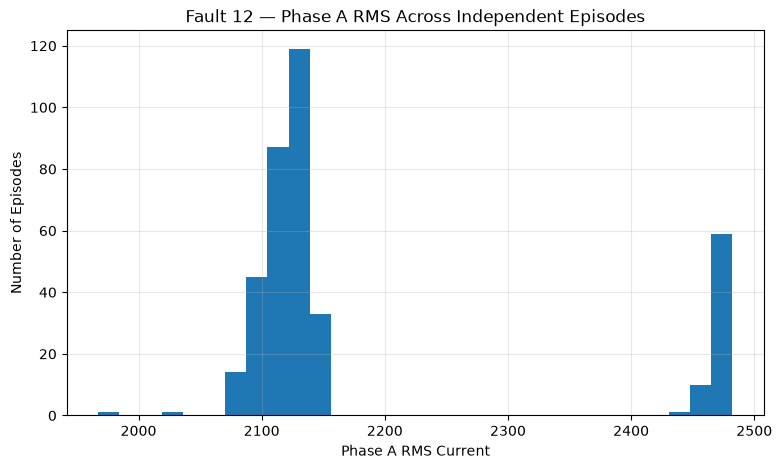

In [61]:
plt.figure(figsize=(9, 5))

plt.hist(
    fault12_rms_a,
    bins=30
)

plt.xlabel("Phase A RMS Current")
plt.ylabel("Number of Episodes")
plt.title("Fault 12 — Phase A RMS Across Independent Episodes")
plt.grid(alpha=0.3)

plt.show()

The RMS distribution is clearly structured rather than a single narrow peak. This shows that independent episodes of the same fault class can occur at different current magnitudes.

This is enough for the initial EDA: the model should not be assumed to operate under one fixed amplitude regime, and deeper investigation of individual fault classes should be deferred until baseline-model errors identify where it is useful.

### 6.3 Optional modeling sanity check: pre-fault operating conditions

As a final modeling sanity check, the Phase-A RMS of the immediately preceding healthy row is compared with the first fault row for each `id_error=12` episode.

In [63]:
fault12_eps = fault_episodes[
    fault_episodes["id_error"] == 12
].copy()

fault12_eps["healthy_row"] = (
    fault12_eps["start_row"].astype(int) - 1
)

In [64]:
needed_rows = set(
    fault12_eps["start_row"].astype(int)
).union(
    fault12_eps["healthy_row"].astype(int)
)

records_needed = {}

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):

        if i in needed_rows:
            records_needed[i] = record

        if len(records_needed) == len(needed_rows):
            break

In [65]:
rows = []

for _, ep in fault12_eps.iterrows():

    fault_row = int(ep["start_row"])
    healthy_row = int(ep["healthy_row"])

    fault_wave = reshape_waveform(
        records_needed[fault_row]["mea_value"]
    )

    healthy_wave = reshape_waveform(
        records_needed[healthy_row]["mea_value"]
    )

    fault_rms = np.sqrt(
        np.mean(fault_wave[:, 0] ** 2)
    )

    healthy_rms = np.sqrt(
        np.mean(healthy_wave[:, 0] ** 2)
    )

    rows.append({
        "fault_episode_id": ep["fault_episode_id"],
        "healthy_rms_A": healthy_rms,
        "fault_rms_A": fault_rms,
        "rms_ratio": fault_rms / healthy_rms,
    })

fault12_rms_compare = pd.DataFrame(rows)

fault12_rms_compare.describe()

,fault_episode_id,healthy_rms_A,fault_rms_A,rms_ratio
count,370.000000,370.000000,370.000000,370.000000
mean,8570.905405,3784.827614,2185.839800,0.723005
std,4867.958494,1138.562999,139.886776,0.485172
min,1.000000,1413.480232,1967.350660,0.468171
25%,4693.250000,4288.958712,2112.038922,0.486931
50%,8916.500000,4307.095312,2128.429101,0.490955
75%,13607.750000,4342.217423,2141.225985,0.495280
max,16000.000000,4443.326248,2482.247682,1.748210


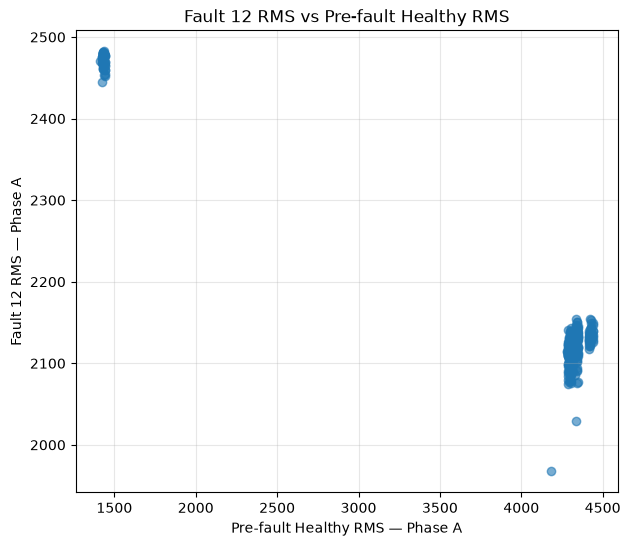

In [66]:
plt.figure(figsize=(7, 6))

plt.scatter(
    fault12_rms_compare["healthy_rms_A"],
    fault12_rms_compare["fault_rms_A"],
    alpha=0.6
)

plt.xlabel("Pre-fault Healthy RMS — Phase A")
plt.ylabel("Fault 12 RMS — Phase A")
plt.title("Fault 12 RMS vs Pre-fault Healthy RMS")
plt.grid(alpha=0.3)

plt.show()

In [67]:
print(
    fault12_rms_compare[
        ["healthy_rms_A", "fault_rms_A", "rms_ratio"]
    ].describe()
)

print(
    "Correlation:",
    fault12_rms_compare[
        ["healthy_rms_A", "fault_rms_A"]
    ].corr().iloc[0, 1]
)

       healthy_rms_A  fault_rms_A   rms_ratio
count     370.000000   370.000000  370.000000
mean     3784.827614  2185.839800    0.723005
std      1138.562999   139.886776    0.485172
min      1413.480232  1967.350660    0.468171
25%      4288.958712  2112.038922    0.486931
50%      4307.095312  2128.429101    0.490955
75%      4342.217423  2141.225985    0.495280
max      4443.326248  2482.247682    1.748210
Correlation: -0.9880816547575341


The scatter plot reveals separated healthy operating regions rather than one narrow healthy amplitude distribution. The strong overall negative correlation is largely driven by these clusters and should **not** be interpreted as a simple continuous physical law.

**Modeling implication:** absolute RMS alone may become a shortcut feature. The classifier should ultimately be evaluated for robustness across operating conditions.

# 7. Outlier Audit

In [4]:
def waveform_stats(mea_value):
    wave = np.asarray(mea_value, dtype=float).reshape(3, 20).T

    return {
        "rms_max": np.sqrt(np.mean(wave**2, axis=0)).max(),
        "peak_abs": np.abs(wave).max(),
        "wave_std": wave.std(),
    }

In [5]:
stats = []

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):

        values = np.asarray(record["mea_value"], dtype=float)

        stats.append({
            "row_id": i,
            "id_error": int(record["id_error"]),
            "has_nan": np.isnan(values).any(),
            "has_inf": np.isinf(values).any(),
            **waveform_stats(values),
        })

outlier_df = pd.DataFrame(stats)

In [6]:
print("NaN rows:", outlier_df["has_nan"].sum())
print("Inf rows:", outlier_df["has_inf"].sum())

print(outlier_df[
    ["rms_max", "peak_abs", "wave_std"]
].describe(percentiles=[
    0.01, 0.05, 0.95, 0.99, 0.999
]))

NaN rows: 0
Inf rows: 0
            rms_max      peak_abs      wave_std
count  3.867050e+05  3.867050e+05  3.867050e+05
mean   3.450117e+06  6.262480e+06  2.752989e+06
std    4.594817e+07  6.866841e+07  3.641330e+07
min    3.048739e+01  6.650924e+01  2.703630e+01
1%     1.209642e+03  2.009500e+03  1.008283e+03
5%     1.436110e+03  2.084775e+03  1.420540e+03
95%    4.516707e+03  6.726582e+03  4.435249e+03
99%    3.288334e+07  6.803294e+07  2.593556e+07
99.9%  1.065375e+09  1.073555e+09  7.676853e+08
max    1.071051e+09  1.073742e+09  1.066249e+09


In [7]:
outlier_df.sort_values(
    "rms_max",
    ascending=False
).head(20)

,row_id,id_error,has_nan,has_inf,rms_max,peak_abs,wave_std
83865,83865,0,False,False,1.071051e+09,1.073658e+09,7.745205e+08
24117,24117,0,False,False,1.071001e+09,1.073733e+09,7.240330e+08
177384,177384,0,False,False,1.070733e+09,1.073723e+09,7.747432e+08
24118,24118,0,False,False,1.070728e+09,1.073739e+09,7.781632e+08
83192,83192,37,False,False,1.070480e+09,1.073730e+09,7.562213e+08
137980,137980,38,False,False,1.070405e+09,1.073698e+09,8.035654e+08
26693,26693,0,False,False,1.070215e+09,1.073692e+09,7.588092e+08
337678,337678,0,False,False,1.070189e+09,1.073698e+09,7.418264e+08
175233,175233,0,False,False,1.070166e+09,1.073725e+09,7.087236e+08
234680,234680,0,False,False,1.070134e+09,1.073682e+09,7.615827e+08


In [8]:
healthy_stats = outlier_df[
    outlier_df["id_error"] == 0
]

healthy_stats["rms_max"].describe(
    percentiles=[0.001, 0.01, 0.99, 0.999]
)

count    2.770410e+05
mean     1.552136e+06
std      3.939244e+07
min      3.048739e+01
0.1%     1.412946e+03
1%       1.423862e+03
99%      4.516221e+03
99.9%    1.065631e+09
max      1.071051e+09
Name: rms_max, dtype: float64

In [9]:
rms_sorted = np.sort(
    outlier_df["rms_max"].values
)

ratios = (
    rms_sorted[1:]
    / rms_sorted[:-1]
)

idx = np.argmax(ratios)

print("Largest jump:")
print("before =", rms_sorted[idx])
print("after  =", rms_sorted[idx + 1])
print("ratio  =", ratios[idx])

Largest jump:
before = 41.575006538441606
after  = 161.7742512097262
ratio  = 3.891141930672806


In [10]:
thresholds = [
    1e4,
    1e5,
    1e6,
    1e7,
    1e8,
    5e8,
    1e9
]

for t in thresholds:
    n = (outlier_df["rms_max"] > t).sum()

    print(
        f"> {t:.0e}: "
        f"{n} rows "
        f"({n / len(outlier_df) * 100:.4f}%)"
    )

> 1e+04: 12873 rows (3.3289%)
> 1e+05: 8704 rows (2.2508%)
> 1e+06: 8039 rows (2.0788%)
> 1e+07: 6348 rows (1.6416%)
> 1e+08: 2918 rows (0.7546%)
> 5e+08: 819 rows (0.2118%)
> 1e+09: 479 rows (0.1239%)


In [11]:
rms = outlier_df["rms_max"].to_numpy()

q99 = np.quantile(rms, 0.99)

upper_tail = np.sort(
    rms[rms >= q99]
)

ratios = upper_tail[1:] / upper_tail[:-1]

idx = np.argmax(ratios)

print("99th percentile:", q99)

print("\nLargest upper-tail jump:")
print("before =", upper_tail[idx])
print("after  =", upper_tail[idx + 1])
print("ratio  =", ratios[idx])

99th percentile: 32883338.512168437

Largest upper-tail jump:
before = 855367346.007213
after  = 884656400.088088
ratio  = 1.0342414919362939


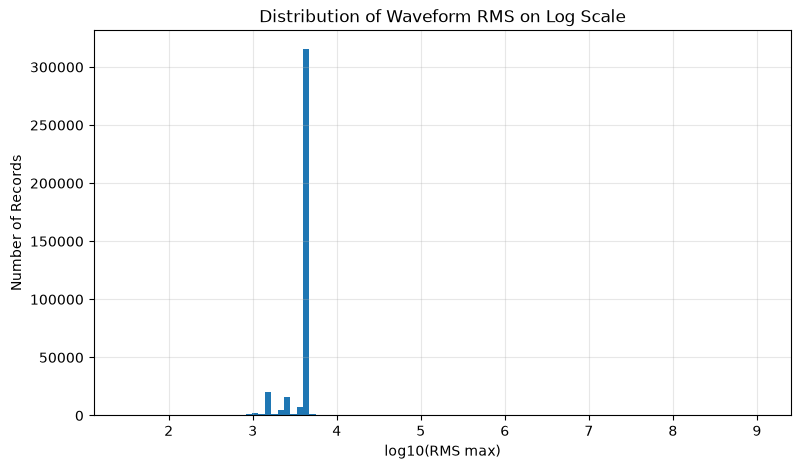

In [12]:
positive_rms = outlier_df.loc[
    outlier_df["rms_max"] > 0,
    "rms_max"
]

plt.figure(figsize=(9, 5))

plt.hist(
    np.log10(positive_rms),
    bins=100
)

plt.xlabel("log10(RMS max)")
plt.ylabel("Number of Records")
plt.title("Distribution of Waveform RMS on Log Scale")
plt.grid(alpha=0.3)

plt.show()

In [13]:
inspect_rows = {83865, 83192, 137980}

inspect_records = {}

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):

        if i in inspect_rows:
            inspect_records[i] = record

        if len(inspect_records) == len(inspect_rows):
            break

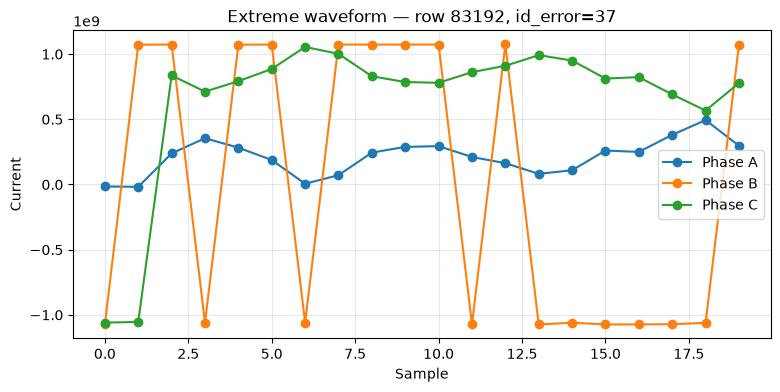

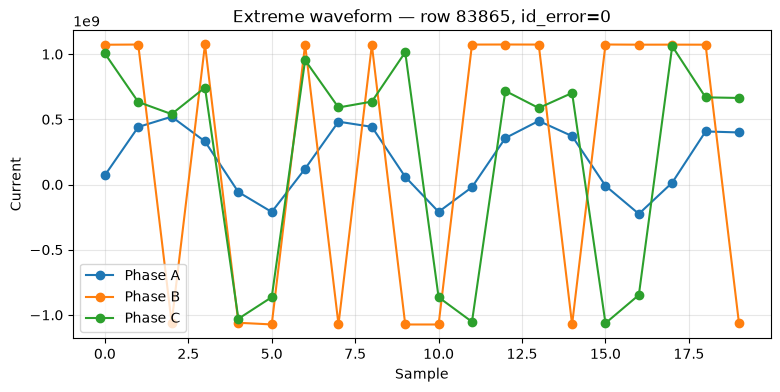

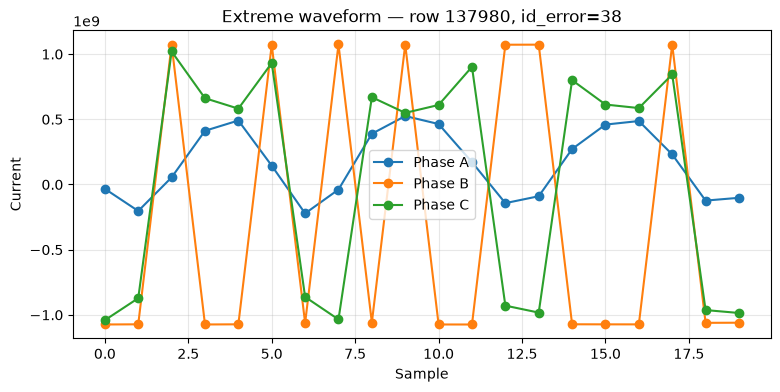

In [16]:
for row_id, record in inspect_records.items():

    wave = reshape_waveform(record["mea_value"])

    plt.figure(figsize=(9, 4))

    plt.plot(wave[:, 0], marker="o", label="Phase A")
    plt.plot(wave[:, 1], marker="o", label="Phase B")
    plt.plot(wave[:, 2], marker="o", label="Phase C")

    plt.title(
        f"Extreme waveform — row {row_id}, "
        f"id_error={record['id_error']}"
    )
    plt.xlabel("Sample")
    plt.ylabel("Current")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [17]:
SAT_VALUE = 2**30
SAT_TOL = 0.01 * SAT_VALUE   # 1% tolerance

def is_saturated(mea_value):
    values = np.asarray(mea_value, dtype=float)

    return np.any(
        np.abs(np.abs(values) - SAT_VALUE) <= SAT_TOL
    )

In [18]:
quality_rows = []

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):
        values = np.asarray(record["mea_value"], dtype=float)

        quality_rows.append({
            "row_id": i,
            "id_error": int(record["id_error"]),
            "is_saturated": is_saturated(values),
        })

quality_df = pd.DataFrame(quality_rows)

In [19]:
print(
    quality_df["is_saturated"].value_counts()
)

print(
    quality_df["is_saturated"]
    .value_counts(normalize=True)
)

print("\nBy label:")
print(
    quality_df.loc[
        quality_df["is_saturated"],
        "id_error"
    ]
    .value_counts()
    .sort_index()
)

is_saturated
False    386101
True        604
Name: count, dtype: int64
is_saturated
False    0.998438
True     0.001562
Name: proportion, dtype: float64

By label:
id_error
0     354
32     44
33     37
34     34
35     40
36     33
37     32
38     30
Name: count, dtype: int64


# 8. EDA summary and modeling implications

## Data integrity

- `id_mea_2` contains **386,705 records**.
- Every record has exactly **60 values = 20 samples × 3 phases**.
- All **48 labels** are represented.
- Healthy (`id_error=0`) accounts for approximately **71.6%** of records; the individual fault classes are comparatively balanced.
- All rows belong to a single experiment/device combination, so `experiment_id` and `device` do not provide a natural split variable.

## Temporal structure

- Timestamps are strictly increasing with no duplicates.
- Normal record cadence is approximately **1 Hz**.
- 99.99% of consecutive timestamp gaps are below approximately **1.019 s**.
- Rare larger gaps behave like acquisition/logging pauses rather than fault transitions.
- Each row is a one-cycle waveform snapshot; rows are not one continuous high-rate waveform stream.

## Episode structure

- The data contain **33,627 label runs**:
  - 16,814 healthy runs
  - 16,813 fault runs
- Transitions alternate strictly between healthy and fault:
  - Healthy → Fault: 16,813
  - Fault → Healthy: 16,814
  - Fault → Fault: 0
- A contiguous non-zero label run is therefore a reasonable **candidate fault episode**.
- Fault classes generally contain **300–400 independent episodes**.

## Waveform structure

- The correct layout is block-wise:
  `A0...A19, B0...B19, C0...C19`.
- Healthy waveforms show a physically plausible balanced three-phase sinusoidal pattern.

## Leakage evidence

A representative `id_error=12` episode shows extremely strong within-episode redundancy:

- Mean pairwise correlation ≈ **0.999985**
- Minimum correlation > **0.99995**
- NRMSE relative to the first record < **1.5%**

Therefore, a random row-level train/test split would place near-duplicate waveforms on both sides of the split and produce overly optimistic evaluation.

## Cross-episode variation

Independent episodes of the same fault class are not exact copies. They vary in starting phase and current magnitude while preserving strongly similar periodic morphology after phase alignment. The healthy baseline also appears to contain more than one operating region.

## Outlier / corruption audit 
No NaN or infinite values were observed. A small subset of waveforms exhibited severe numerical saturation near ±\(2^{30}\), producing nonphysical clipped waveforms across both healthy and fault labels. These records were flagged as invalid and excluded from modeling. Other statistically extreme waveforms were retained because amplitude and waveform distortion can represent legitimate operating or fault conditions.

## Decisions for the next stage

| EDA finding | Modeling consequence |
|---|---|
| Healthy class dominates record count | Report macro-F1 and per-class recall in addition to accuracy |
| Same-episode rows are near-duplicates | **Split by episode, never randomly by row** |
| Independent episodes vary in phase | Avoid relying on a fixed waveform starting phase; consider phase-shift robustness later |
| Operating amplitude varies | Do not assume absolute RMS alone defines a fault |
| Input is a structured 20×3 time series | 1D CNN / TCN remains a reasonable modeling direction |

## EDA stopping rule

Initial EDA is complete when it has resolved issues that affect **data integrity, preprocessing, split strategy, metrics, model assumptions, or evaluation validity**.

We do **not** repeat this detailed waveform analysis for all 47 fault types before modeling. After a baseline classifier is trained, the confusion matrix and per-class metrics should identify which fault pairs require targeted follow-up EDA.

### Next step

Construct an **episode-aware train / validation / test split** and verify that:

1. no fault episode appears in more than one split;
2. all labels are represented appropriately;
3. class/episode distributions remain reasonable across splits.